# Notebook 1 - Exploration ConceptNet

Ce notebook montre comment :
- interroger ConceptNet en ligne,
- filtrer les relations utiles,
- construire un petit sous-graphe,
- visualiser les voisinages et les chemins,
- verbaliser les faits récupérés.

L’idée est de présenter une petite démonstration locale et compréhensible, sans dépendre d’une architecture lourde.

In [1]:
import json
import requests
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt

print("Connexion ConceptNet : test sur le concept milk")
url = "https://api.conceptnet.io/c/en/milk"
cache_path = Path("../data/cache/conceptnet_milk.json")
cache_path.parent.mkdir(parents=True, exist_ok=True)
payload = {"edges": []}

try:
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    payload = response.json()
    cache_path.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")

    print("ConceptNet live disponible.")
    print("Structure de la réponse :")
    print("Clés de la racine:", list(payload.keys()))
    first_edge = payload["edges"][0]
    print("Exemple d’arête :")
    print(json.dumps({
        "start": first_edge.get("start", {}).get("label"),
        "rel": first_edge.get("rel", {}).get("label"),
        "end": first_edge.get("end", {}).get("label"),
        "weight": first_edge.get("weight"),
        "surfaceText": first_edge.get("surfaceText"),
    }, ensure_ascii=False, indent=2))

    print("Nombre d’arêtes récupérées :", len(payload.get("edges", [])))
    print(json.dumps(payload.get("edges", [])[:3], indent=2)[:800])
except Exception as exc:
    print("ConceptNet live indisponible (", exc, ").")
    if cache_path.exists():
        payload = json.loads(cache_path.read_text(encoding="utf-8"))
        print("Utilisation du cache local pour maintenir la démo.")
        print("Nombre d’arêtes récupérées depuis le cache :", len(payload.get("edges", [])))
        print(json.dumps(payload.get("edges", [])[:3], indent=2)[:800])
    else:
        print("Aucun cache local disponible. Le notebook continue avec une version vide.")

        payload = {"edges": []}

Connexion ConceptNet : test sur le concept milk
ConceptNet live indisponible ( 502 Server Error: Bad Gateway for url: https://api.conceptnet.io/c/en/milk ).
Utilisation du cache local pour maintenir la démo.
Nombre d’arêtes récupérées depuis le cache : 8
[
  {
    "start": {
      "label": "milk",
      "language": "en",
      "@id": "/c/en/milk"
    },
    "end": {
      "label": "drink",
      "language": "en",
      "@id": "/c/en/drink"
    },
    "rel": {
      "label": "UsedFor"
    },
    "weight": 2.0,
    "surfaceText": "milk is used for drink"
  },
  {
    "start": {
      "label": "milk",
      "language": "en",
      "@id": "/c/en/milk"
    },
    "end": {
      "label": "food",
      "language": "en",
      "@id": "/c/en/food"
    },
    "rel": {
      "label": "IsA"
    },
    "weight": 1.8,
    "surfaceText": "milk is a kind of food"
  },
  {
    "start": {
      "label": "milk",
      "language": "en",
      "@id": "/c/en/milk"
    },
    "end": {
      "label": "refrige

In [2]:
# Filtrage des relations les plus utiles
allowed = {"IsA", "UsedFor", "CapableOf", "Causes", "HasProperty", "AtLocation"}
interesting_edges = []
for edge in payload.get("edges", []):
    label = edge.get("rel", {}).get("label", "RelatedTo")
    if label in allowed:
        interesting_edges.append(edge)

print("Relations filtrées :", len(interesting_edges))
if not interesting_edges:
    print("Aucune arête utile n’a été trouvée dans le payload courant.")

else:        
    for edge in interesting_edges[:5]:
        print(edge.get("rel", {}).get("label"), "->", edge.get("start", {}).get("label"), "->", edge.get("end", {}).get("label"))

Relations filtrées : 8
UsedFor -> milk -> drink
IsA -> milk -> food
AtLocation -> milk -> refrigerator
HasProperty -> milk -> white
CapableOf -> cow -> produce milk


Nœuds : 10
Arêtes : 8


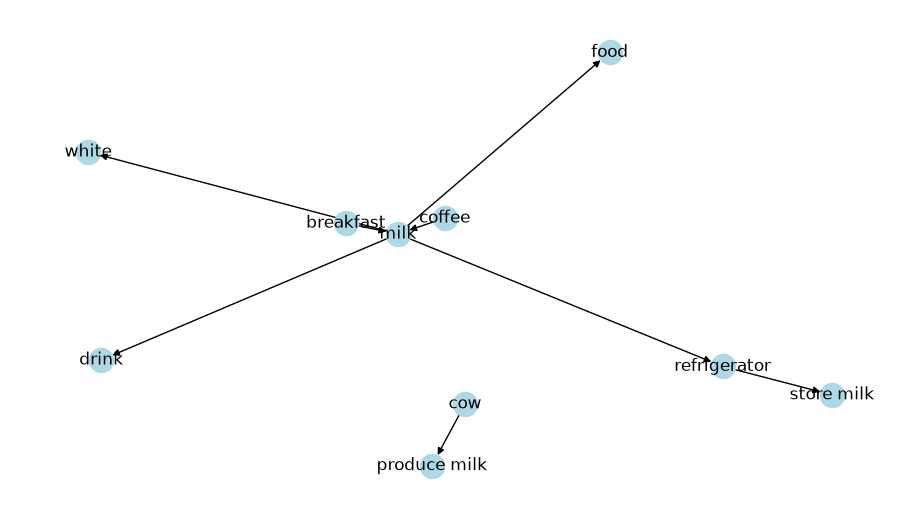

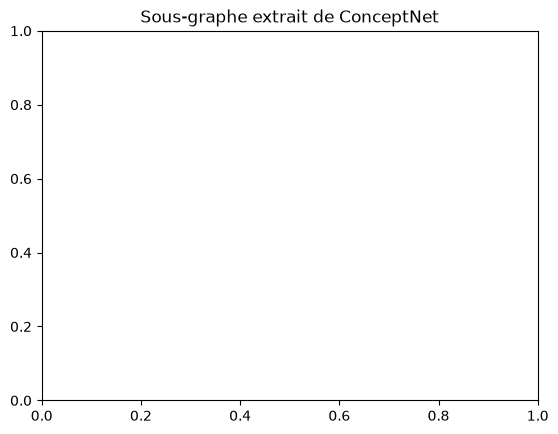

In [5]:
# Construction d’un petit sous-graphe
G = nx.DiGraph()
for edge in interesting_edges[:10]:
    start = edge.get("start", {}).get("label", "start")
    end = edge.get("end", {}).get("label", "end")
    rel = edge.get("rel", {}).get("label", "RelatedTo")
    G.add_edge(start, end, relation=rel)

print("Nœuds :", G.number_of_nodes())
print("Arêtes :", G.number_of_edges())

if G.number_of_edges() == 0:
    print("Pas assez de faits pour dessiner un sous-graphe utile ; le cache local est peut-être insuffisant.")
else:
    plt.figure(figsize=(9, 5))
    nx.draw(G, with_labels=True, arrows=True, node_color="lightblue")    
    plt.show()
    plt.title("Sous-graphe extrait de ConceptNet")

In [6]:
# Verbalisation simple des faits
relations = {
    "IsA": lambda s, o: f"{s} is a type of {o}.",
    "UsedFor": lambda s, o: f"{s} is used for {o}.",
    "CapableOf": lambda s, o: f"{s} is capable of {o}.",
    "Causes": lambda s, o: f"{s} can cause {o}.",
    "HasProperty": lambda s, o: f"{s} has the property of being {o}.",
    "AtLocation": lambda s, o: f"{s} is usually found at {o}.",
}

for edge in interesting_edges[:4]:
    rel = edge.get("rel", {}).get("label", "RelatedTo")
    s = edge.get("start", {}).get("label", "")
    e = edge.get("end", {}).get("label", "")
    if rel in relations:
        print(relations[rel](s, e))

milk is used for drink.
milk is a type of food.
milk is usually found at refrigerator.
milk has the property of being white.


### Conclusion

On voit ici qu’un petit sous-graphe ConceptNet peut fournir des faits structurés et lisibles, qui peuvent ensuite être injectés dans un prompt pour un LLM local.

In [7]:
from collections import Counter

relation_counts = Counter(edge.get("rel", {}).get("label", "RelatedTo") for edge in payload.get("edges", []))
print("Répartition des relations :")
for rel, count in relation_counts.most_common(5):
    print(rel, count)


Répartition des relations :
UsedFor 3
HasProperty 2
IsA 1
AtLocation 1
CapableOf 1
